# &laquo;Машинное обучение&raquo;, AI Masters

### Домашняя работа №7. Бинарное дерево решений, случайный лес.

### Задача 1 (2 балла)

1. закончить реализацию `ClassificationDecisionTree` в decision_tree
    1. реализовать feature_importance_ (для этого метода теста нет, подойдет реализацию любого варианта, базовый способ - рекурсивно суммировать по всем `self.feature_id` `self.q_value_max` и вывести суммы. ✅
    2. проверить корректность predict  ✅
2. реализовать `BaseSampler`, `ObjectSampler` и `FeatureSampler`. `BaseSampler` - базовый класс, у которого должен быть реализован метода `sample_indices` - вернуть индексы сэмплов. `ObjectSampler` сэплирует объекты, `FeatureSampler` - признаки. ✅
3. реализовать `RandomForestClassifier` в random_forest (predict/predict_proba). ✅

Обратите внимение, что в random_forest в качестве `base_estimator` предполагается использовать `DecisionTreeClassifier` из sklearn, использовать вашу реализацию решающего дерева необязательно. <br> Пример запуска тестов 
- `python -m unittest discover sem_dt_rf/decision_tree/tests` ✅
- `python -m unittest discover sem_dt_rf/random_forest/tests` ✅

Или через `pytest`
- `python -m pytest sem_dt_rf/decision_tree/tests/test_criterio.py` ✅


Также `sem_dt_rf/decision_tree/check_results.ipynb` работает верно   ✅

In [1]:
!python -m pytest sem_dt_rf/decision_tree/tests/test_criterio.py
!python -m pytest sem_dt_rf/decision_tree/tests/test_decision_tree.py
!python -m pytest sem_dt_rf/decision_tree/tests/test_tree_node.py

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-9.0.2, pluggy-1.6.0
rootdir: /mnt/calc/lizzzafomenko/aim
plugins: anyio-4.12.1
collected 8 items                                                              

sem_dt_rf/decision_tree/tests/test_criterio.py ........                  [100%]

============================== 8 passed in 0.13s ===============================
============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-9.0.2, pluggy-1.6.0
rootdir: /mnt/calc/lizzzafomenko/aim
plugins: anyio-4.12.1
collected 2 items                                                              

sem_dt_rf/decision_tree/tests/test_decision_tree.py ..                   [100%]

============================== 2 passed in 0.14s ===============================
============================= test session starts ==============================
platform linux -- Python 3.12.1

In [2]:
!python -m pytest sem_dt_rf/random_forest/tests/test_sampler.py
!python -m pytest sem_dt_rf/random_forest/tests/test_random_forest.py

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-9.0.2, pluggy-1.6.0
rootdir: /mnt/calc/lizzzafomenko/aim
plugins: anyio-4.12.1
collected 5 items                                                              

sem_dt_rf/random_forest/tests/test_sampler.py .....                      [100%]

============================== 5 passed in 0.14s ===============================
============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-9.0.2, pluggy-1.6.0
rootdir: /mnt/calc/lizzzafomenko/aim
plugins: anyio-4.12.1
collected 3 items                                                              

sem_dt_rf/random_forest/tests/test_random_forest.py ...                  [100%]

============================== 3 passed in 0.13s ===============================


### Задача 2 (1 балл)

Для регрессионного дерева необходимо использовать такой критерий:

$$H(R) = \min_c \frac{1}{|R|} \sum_{(x_i, y_i) \in R} (y_i - c)^2$$

Докажите, что минимум $H(R)$ достигается при следующем $c$:

$$ c = \frac{1}{|R|} \sum_{(x_j, y_j) \in R} y_j$$

$$\frac{1}{|R|} \sum_{(x_i, y_i) \in R} (y_i - c)^2 -> min$$

избавляемся от константы

$$\sum_{(x_i, y_i) \in R} (y_i - c)^2 -> min$$

берем производную по $c$ и приравниваем к $0$

$$\frac{d}{d c}(\sum_{(x_i, y_i) \in R} (y_i - c)^2) = 0$$

$$\sum_{(x_i, y_i) \in R} \frac{d}{d c}(y_i - c)^2 = 0$$

$$\sum_{(x_i, y_i) \in R} \frac{d}{d c}(y_i^2 - 2y_i*c + c^2) = 0$$

$$\sum_{(x_i, y_i) \in R} (-2y_i + 2c) = 0$$

$$2\sum_{(x_i, y_i) \in R} (c - y_i) = 0$$

избавляемся от константы, выносим $c$ из суммы

$$|R| * c - \sum_{(x_i, y_i) \in R} y_i = 0$$

$$|R| * c = \sum_{(x_i, y_i) \in R} y_i$$

$$|R| * c = \sum_{(x_i, y_i) \in R} y_i$$

$$ c = \frac{1}{|R|} \sum_{(x_i, y_i) \in R} y_i$$

### Задача 3 (3 балла)

Реализуйте `class RegressionDecisionTree(DecisionTree)` -- регрессионное дерево.

* В качестве критерия необходимо использовать критерий, определённый в пункте 2 (для этого в коде есть заглушка `MSECriterion`).
* В качестве `predict` необходимо использовать среднее значение ответов по всем объектам в листе. В коде нет готовой заглушки, реализуйте по аналогии с `class ClassificationDecisionTree(DecisionTree):`.

Сгенерируйте однопризнаковую выборку для тестирования дерева и покажите работу дерева на этой выборке (пример см. ниже, можно использовать свою версию). Отобразите на одном графике `predict` алгоритма и значение признака. Что меняется при изменении параметра глубины? Сделайте выводы.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# generate example
x_shape = 300
x = np.arange(x_shape) / 100
y = x**3 * np.sin(x**3) + np.random.random(x_shape)

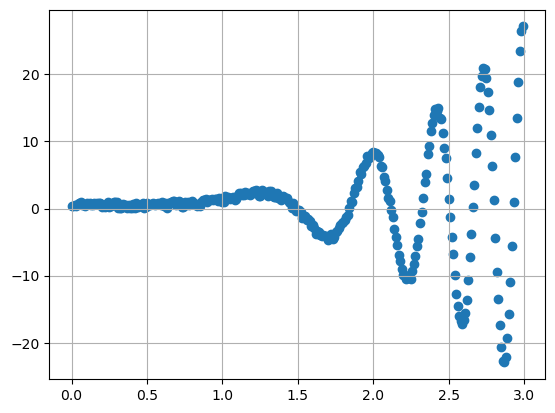

In [5]:
plt.scatter(x, y)
plt.grid()
plt.show()

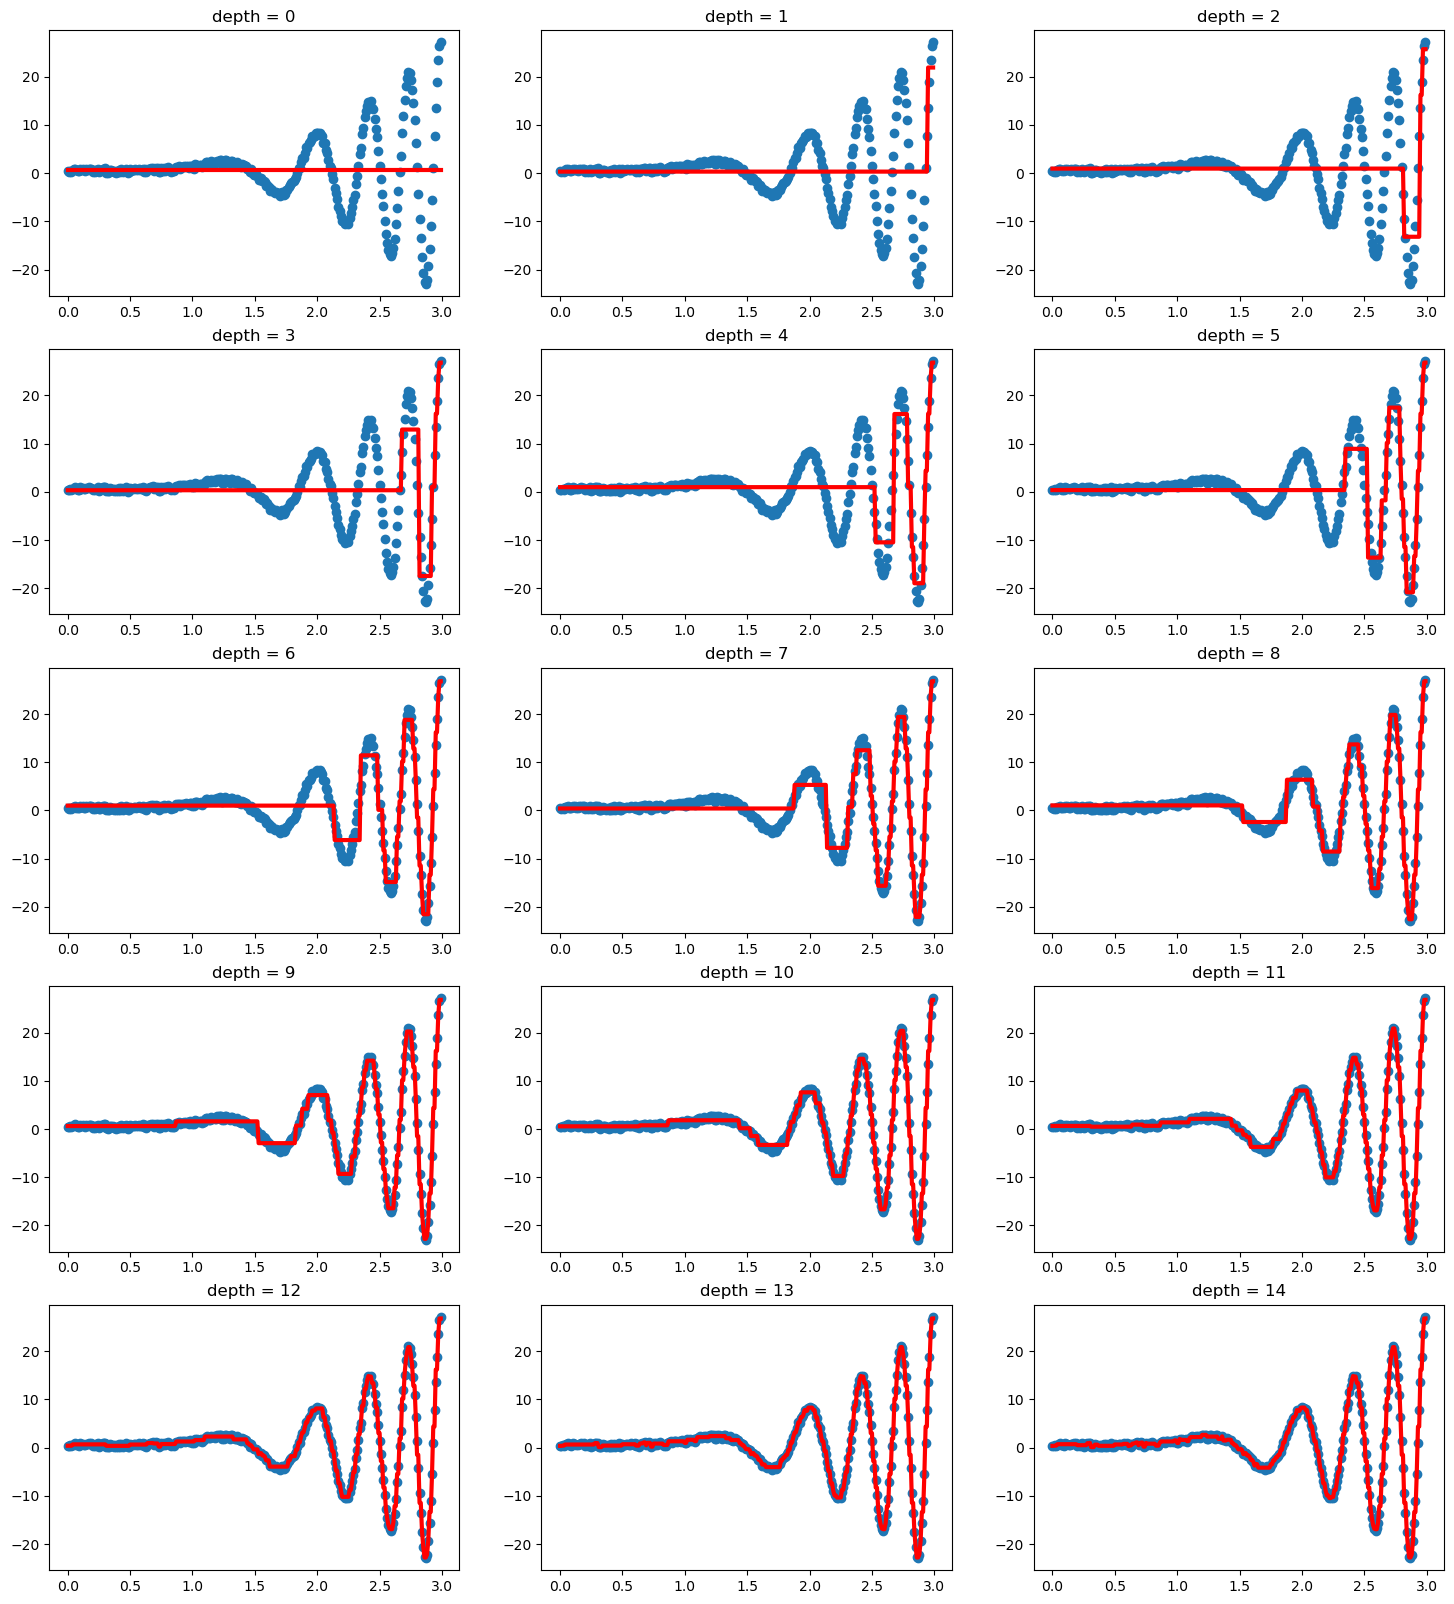

In [6]:
%load_ext autoreload
%autoreload 2
from sem_dt_rf.decision_tree.decision_tree import RegressionDecisionTree

f, axes = plt.subplots(nrows = 5, ncols = 3, figsize = (18,20))

for depth in range(15):
    regr_tree = RegressionDecisionTree(criterion='mse', max_depth=depth, min_leaf_size=2)
    regr_tree.fit(x.reshape(-1,1), y)
    predictions = regr_tree.predict(x.reshape(-1,1))
    i, j = depth // 3, depth % 3
    axes[i, j].scatter(x, y)
    axes[i, j].plot(x, predictions, color = 'red', lw=3 )
    axes[i, j].set_title(f'depth = {depth}')

In [7]:
# чем больше глубина, тем сильнее переобучается - последний ряд практически выучил выборку, идеально ловит форму

# тут функция слабо зашумлена, поэтому не видно гиперобучения. если взять менее зашумленную:

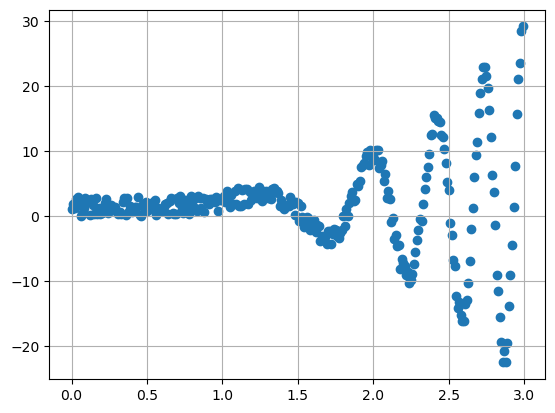

In [8]:
# generate example
x_shape = 300
x = np.arange(x_shape) / 100
y = x**3 * np.sin(x**3) + np.random.random(x_shape)*3

plt.scatter(x, y)
plt.grid()
plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


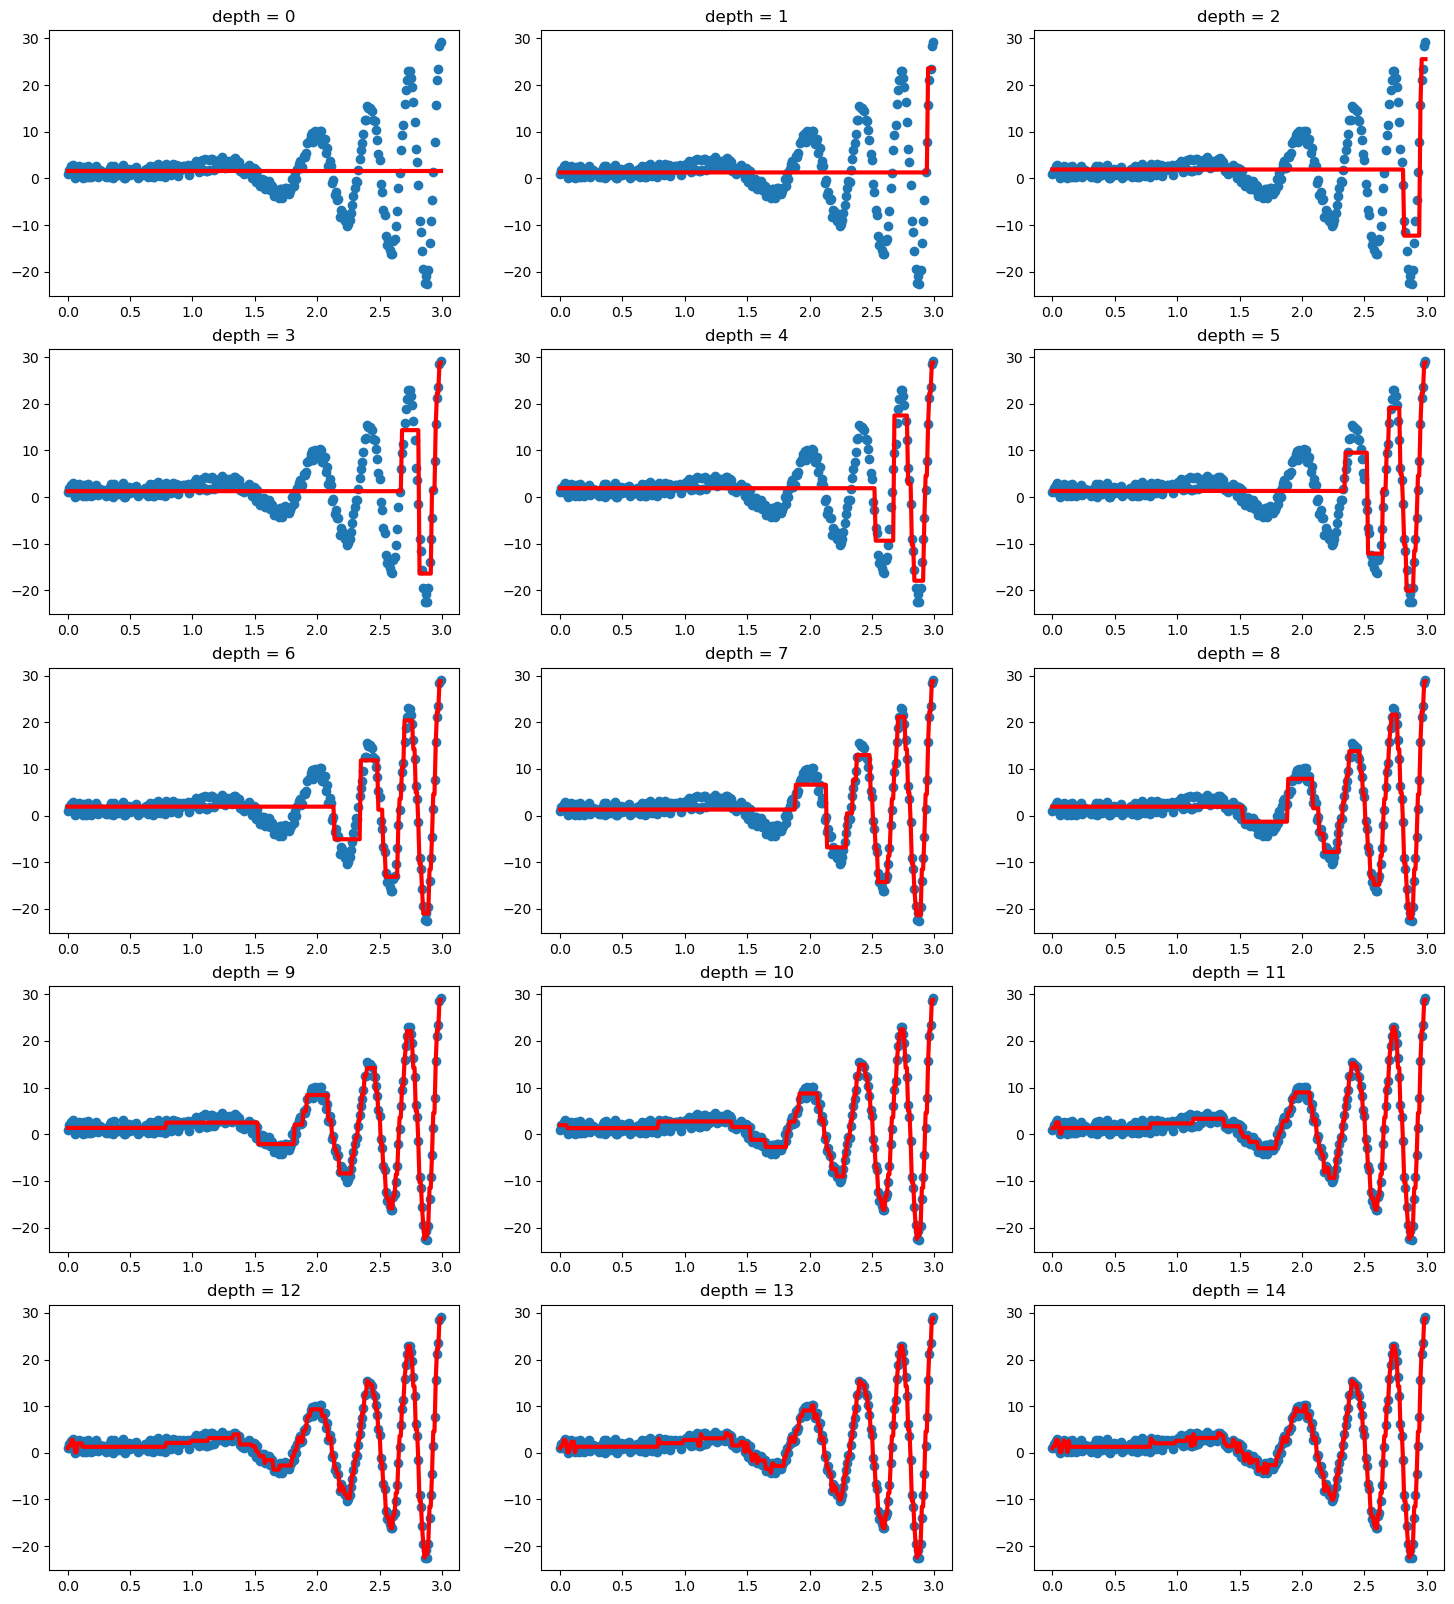

In [9]:
%load_ext autoreload
%autoreload 2
from sem_dt_rf.decision_tree.decision_tree import RegressionDecisionTree

f, axes = plt.subplots(nrows = 5, ncols = 3, figsize = (18,20))

for depth in range(15):
    regr_tree = RegressionDecisionTree(criterion='mse', max_depth=depth, min_leaf_size=2)
    regr_tree.fit(x.reshape(-1,1), y)
    predictions = regr_tree.predict(x.reshape(-1,1))
    i, j = depth // 3, depth % 3
    axes[i, j].scatter(x, y)
    axes[i, j].plot(x, predictions, color = 'red', lw=3 )
    axes[i, j].set_title(f'depth = {depth}')

In [10]:
# вот тут уже лучше видно, особенно в части с мЕньшеми X, прям суперски переобучила. оптимально тут 9-10 глубина кмк

### Задача 4 (4 балла)

Протестируйте различные реализации **случайного леса** на `fetch_covtype` датасете (можно загрузить с помощью `sklearn.datasets.fetch_covtype`). Возможно, поможет ноутбук с семинара `ensembles_seminar.ipynb`.

Для честного сравнения старайтесь использовать похожий набор гиперпараметров.

Сравните следующие модели:
- ваша реализация (`import RandomForestClassifier as MyRandomForestClassifier` ниже)
- Scikit-learn [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- XGBoost [`XGBRFClassifier`](https://xgboost.readthedocs.io/en/stable/tutorials/rf.html)
- LightGBM [`LGBMClassifier`](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMModel.html) см. параметр `boosting_type`

Что нужно сделать: 
- Разбейте данные на train и test. 
- Оцените качество алгоритмов по метрике [`balanced_accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html)
- Оцените время работы `train` и `predict`
- Найдите, в каких из модулей (помимо вашего) реализовано вычисление важностей признаков. Сравните выдаваемые importances в моделях с такой функцией
- Сделайте выводы

In [1]:
import sys
sys.path.extend(['/mnt/calc/lizzzafomenko/aim']) 

In [2]:
%load_ext autoreload
%autoreload 2
from sem_dt_rf.random_forest.random_forest import RandomForestClassifier as MyRandomForestClassifier

In [3]:
from sklearn.datasets import fetch_covtype
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
import lightgbm
import xgboost
import pandas as pd
import numpy as np
import time 


In [4]:
cov_type = fetch_covtype()

In [5]:
cov_type['data'].shape, cov_type['target'].shape

((581012, 54), (581012,))

In [6]:
x_train, x_test, y_train, y_test = train_test_split(cov_type['data'], cov_type['target'] - 1, test_size = 0.33, random_state = 57)

In [7]:
my_kwargs = {"max_objects_samples": 0.9,
"max_features_samples": 0.8,
"min_samples_leaf": 5,
"random_state": 57,
"criterion": 'gini',
"bootstrap": True,
"verbose": 1}

sklearn_kwargs = {"criterion": 'gini', 
"min_samples_split": 2,
"min_samples_leaf": 5, 
"max_features": 0.9,
"random_state": 57,
"bootstrap": True}

lgbm_kwargs = {"boosting_type": 'rf',
"num_leaves": 2, 
"objective": 'multiclass',
"random_state": 57,
"importance_type": 'gain',
"min_child_samples": 5,
"colsample_bytree": 0.9,
"subsample": 0.8,
"num_class": 7,
"verbose": 0}

xgb_kwargs = {"colsample_bynode": 0.9,
"max_leaves": 0,
"grow_policy": 'lossguide',
"booster": 'gbtree',
"subsample": 0.8,
"random_state": 57,
"importance_type": 'total_gain'}

In [ ]:
RFs = [MyRandomForestClassifier, RandomForestClassifier, lightgbm.LGBMModel, xgboost.XGBRFClassifier]
names = ['My RFClass', 'sklearn RFClass', 'Lightbgm RFClass', 'XgBoost RFClass']
kwargs = [my_kwargs, sklearn_kwargs, lgbm_kwargs, xgb_kwargs]

In [9]:
accs = []
fit_times = []
predict_times = []
feature_imp = []

n_estimators = 10
for i, rf in enumerate(RFs):
    print(f'start working with {names[i]}')
    acc_rf = []
    fit_times_rf = []
    predict_times_rf = []
    feature_imp_rf = []

    for max_depth in [2, 5, 7, 10]:

        print(f'    max_depth = {max_depth}')

        model = rf(n_estimators = n_estimators, max_depth = max_depth, **kwargs[i])

        # fit 
        print('     fitting....')
        start = time.time()
        model.fit(x_train, y_train)
        end = time.time()
        fit_time = end - start

        # make predictions
        print('     predicting....')
        start = time.time()
        predictions = model.predict(x_test)
        end = time.time()
        prediction_time = end - start 

        print('got_predictions')

        if names[i] == 'Lightbgm RFClass':
            predictions = predictions.argmax(axis=1)

        # get accuracy
        acc = balanced_accuracy_score(y_test, predictions)
        print('got accuracy')
        print(acc)

        acc_rf.append(acc)
        fit_times_rf.append(fit_time)
        predict_times_rf.append(prediction_time)
        if names[i] == 'My RFClass':
            feature_imp_rf.append(model.feature_importances_())
        else:
            feature_imp_rf.append(model.feature_importances_)
    
    accs.append(acc_rf)
    fit_times.append(fit_times_rf)
    predict_times.append(predict_times_rf)
    feature_imp.append(feature_imp_rf)


start working with My RFClass
    max_depth = 2
     fitting....
fitting tree num 0
fitting tree num 1
fitting tree num 2
fitting tree num 3
fitting tree num 4
fitting tree num 5
fitting tree num 6
fitting tree num 7
fitting tree num 8
fitting tree num 9
     predicting....
got_predictions
got accuracy
0.3079096179783766
    max_depth = 5
     fitting....
fitting tree num 0
fitting tree num 1
fitting tree num 2
fitting tree num 3
fitting tree num 4
fitting tree num 5
fitting tree num 6
fitting tree num 7
fitting tree num 8
fitting tree num 9
     predicting....
got_predictions
got accuracy
0.3947087004467867
    max_depth = 7
     fitting....
fitting tree num 0
fitting tree num 1
fitting tree num 2
fitting tree num 3
fitting tree num 4
fitting tree num 5
fitting tree num 6
fitting tree num 7
fitting tree num 8
fitting tree num 9
     predicting....
got_predictions
got accuracy
0.46825064912092607
    max_depth = 10
     fitting....
fitting tree num 0
fitting tree num 1
fitting tree num

/mnt/calc/lizzzafomenko/condaenvs/lizaim/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMModel was fitted with feature names
  warnings.warn(


     predicting....
got_predictions
got accuracy
0.46930777120886974
    max_depth = 7
     fitting....


/mnt/calc/lizzzafomenko/condaenvs/lizaim/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMModel was fitted with feature names
  warnings.warn(


     predicting....
got_predictions
got accuracy
0.46930777120886974
    max_depth = 10
     fitting....


/mnt/calc/lizzzafomenko/condaenvs/lizaim/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMModel was fitted with feature names
  warnings.warn(


     predicting....
got_predictions
got accuracy
0.46930777120886974
start working with XgBoost RFClass
    max_depth = 2
     fitting....


/mnt/calc/lizzzafomenko/condaenvs/lizaim/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMModel was fitted with feature names
  warnings.warn(


     predicting....
got_predictions
got accuracy
0.4999018711156464
    max_depth = 5
     fitting....
     predicting....
got_predictions
got accuracy
0.6838170139223303
    max_depth = 7
     fitting....
     predicting....
got_predictions
got accuracy
0.7385962895932451
    max_depth = 10
     fitting....
     predicting....
got_predictions
got accuracy
0.8326665116034652


я поставила n_estimators=2 и max_depth=1 и наше дерево работало просто БЕСКОНЕЧНО

поэтому пришлось переписать: делается не самая умная вещь, просто берем каждый n-й x из упорядоченных

In [ ]:
# было
def get_best_split(self, feature: np.ndarray, target: np.ndarray) -> Tuple[float, float]:
        ind = np.argsort(feature)
        feature_sorted = feature[ind]
        target_sorted = target[ind]
        q_all = self.score(target)

        q_max, i_max = -np.inf, -1
        for i in range(5, len(feature_sorted)-5, max(len(feature_sorted)//500, 1)):  # <- вот здесь 1) чтобы не было дурацких разделений сразу оставляем 5 объектов слева и справа
                                                                                     # 2) дабы избежать бесконечной работы делаем либо <= 500 шагов 
            q_left = self.score(target_sorted[:i])
            q_right = self.score(target_sorted[i:])
            q_current = q_all
            q_current -= (i + 1) / len(feature_sorted) * q_left
            q_current -= (len(feature_sorted) - i - 1) / len(feature_sorted) * q_right
            if q_current > q_max:
                q_max = q_current
                i_max = i

        threshold = (feature_sorted[i_max] + feature_sorted[i_max - 1]) / 2
        return threshold, q_max



# надо сильно уменьшать перебор, потому что сейчас это капец как долго

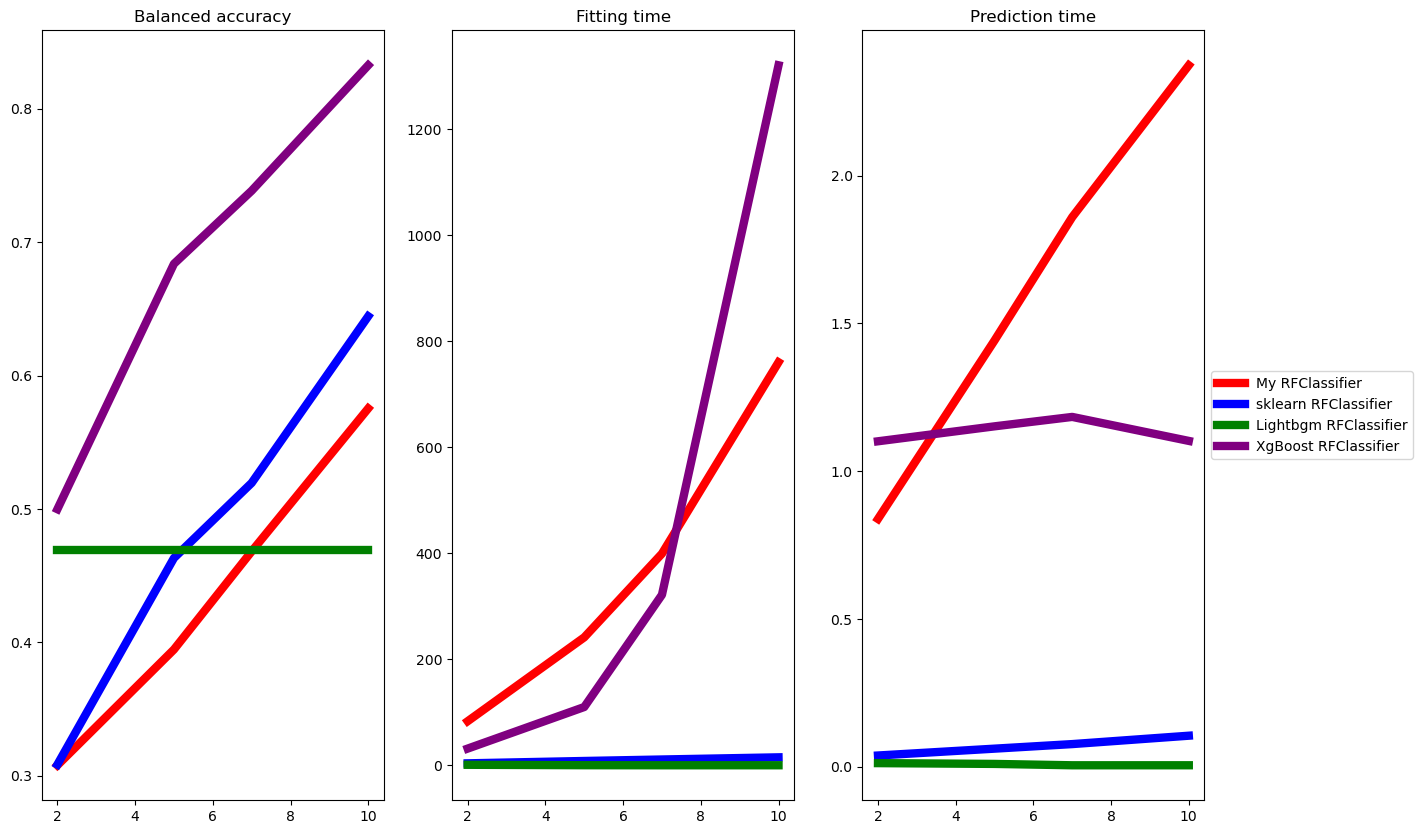

In [13]:
f, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (15, 10))

depths = np.array([2, 5, 7, 10])
accs = np.array(accs)
fit_times =  np.array(fit_times)
predict_times =  np.array(predict_times)

axes[0].plot(depths, accs[0], c='red', linewidth=6)
axes[0].plot(depths, accs[1], c='blue', linewidth=6)
axes[0].plot(depths, accs[2], c='green', linewidth=6)
axes[0].plot(depths, accs[3], c='purple', linewidth=6)
axes[0].set_title(f'Balanced accuracy')

axes[1].plot(depths, fit_times[0], c='red', linewidth=6)
axes[1].plot(depths, fit_times[1], c='blue', linewidth=6)
axes[1].plot(depths, fit_times[2], c='green', linewidth=6)
axes[1].plot(depths, fit_times[3], c='purple', linewidth=6)
axes[1].set_title(f'Fitting time')

axes[2].plot(depths, predict_times[0], c='red', label='My RFClassifier', linewidth=6)
axes[2].plot(depths, predict_times[1], c='blue', label='sklearn RFClassifier', linewidth=6)
axes[2].plot(depths, predict_times[2], c='green', label='Lightbgm RFClassifier', linewidth=6)
axes[2].plot(depths, predict_times[3], c='purple', label='XgBoost RFClassifier', linewidth=6)
axes[2].set_title(f'Prediction time')

axes[2].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [ ]:
# извините за уродский график

0


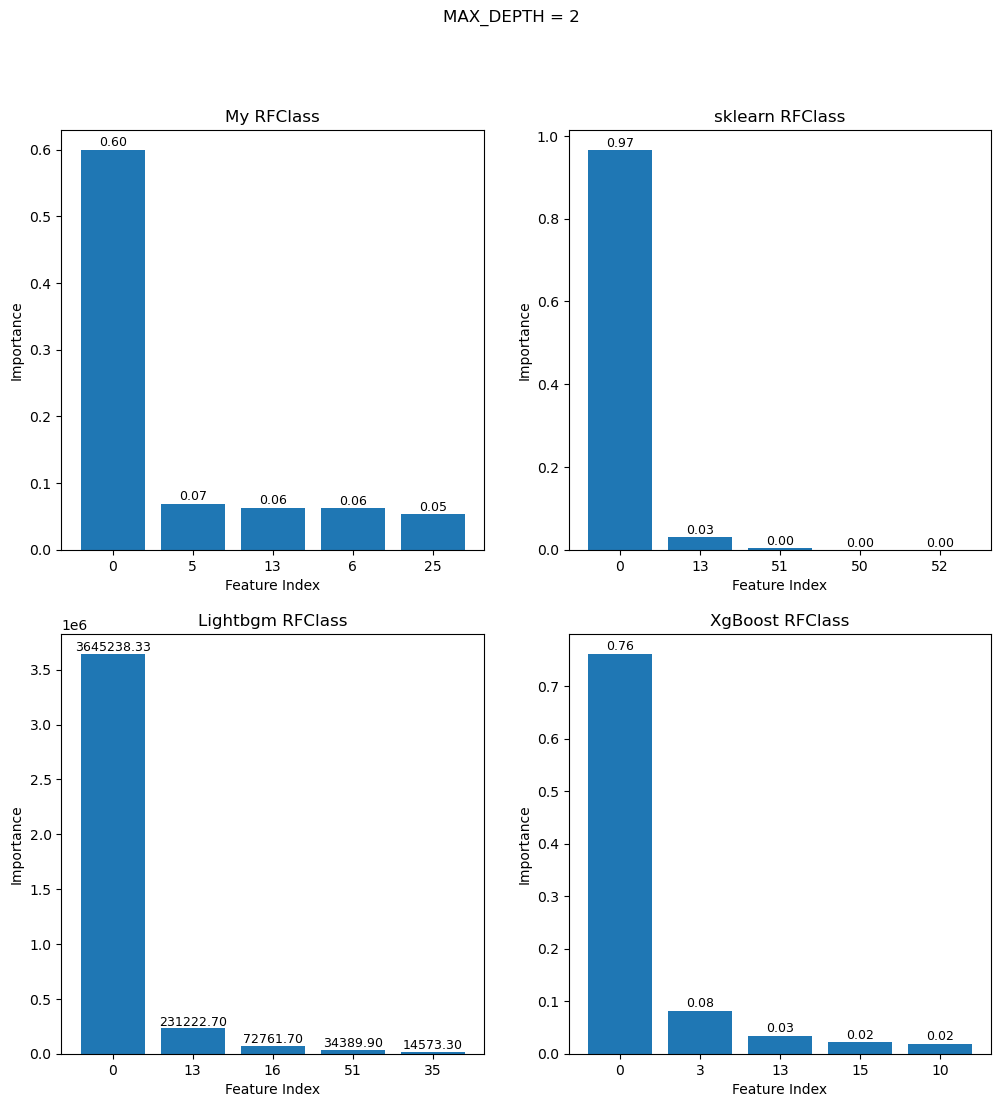

1


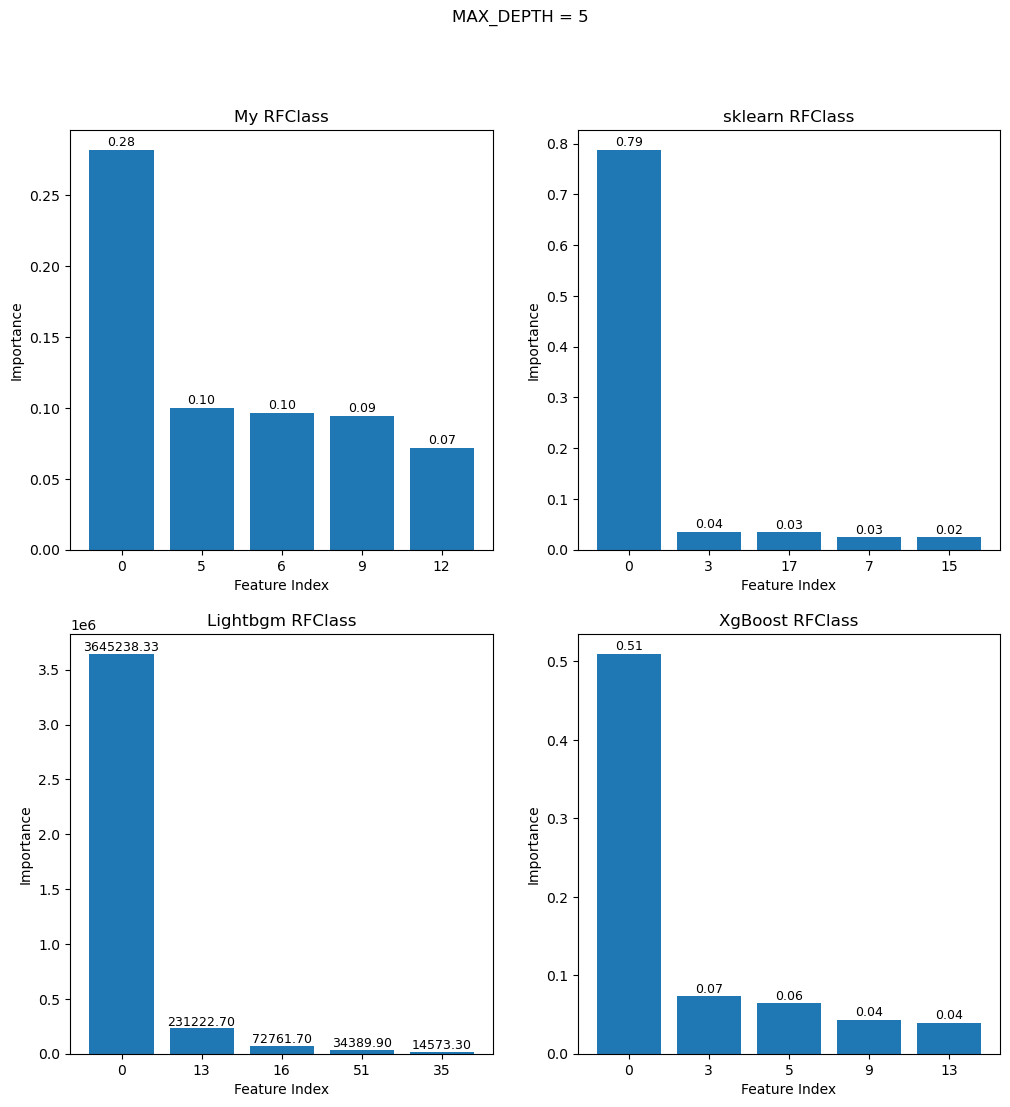

2


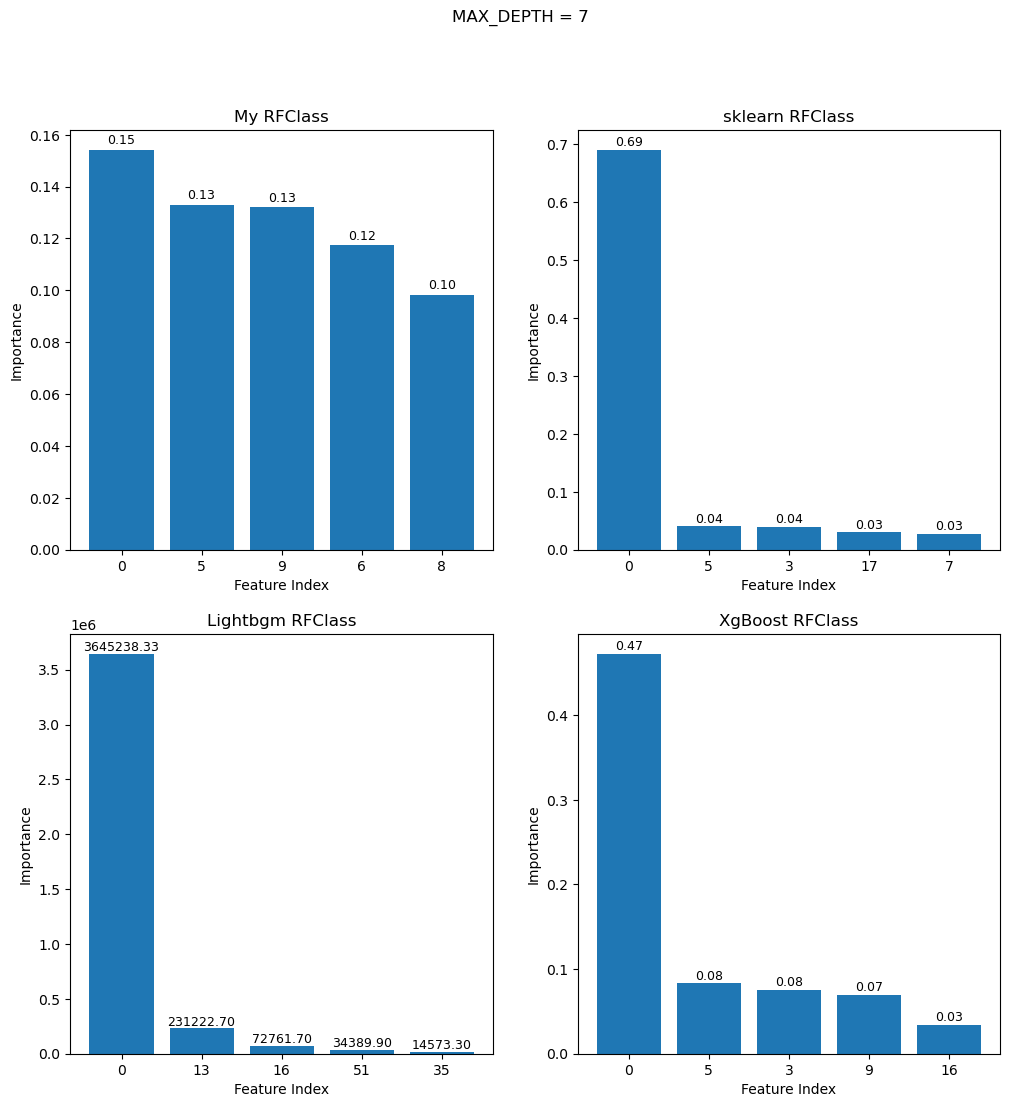

3


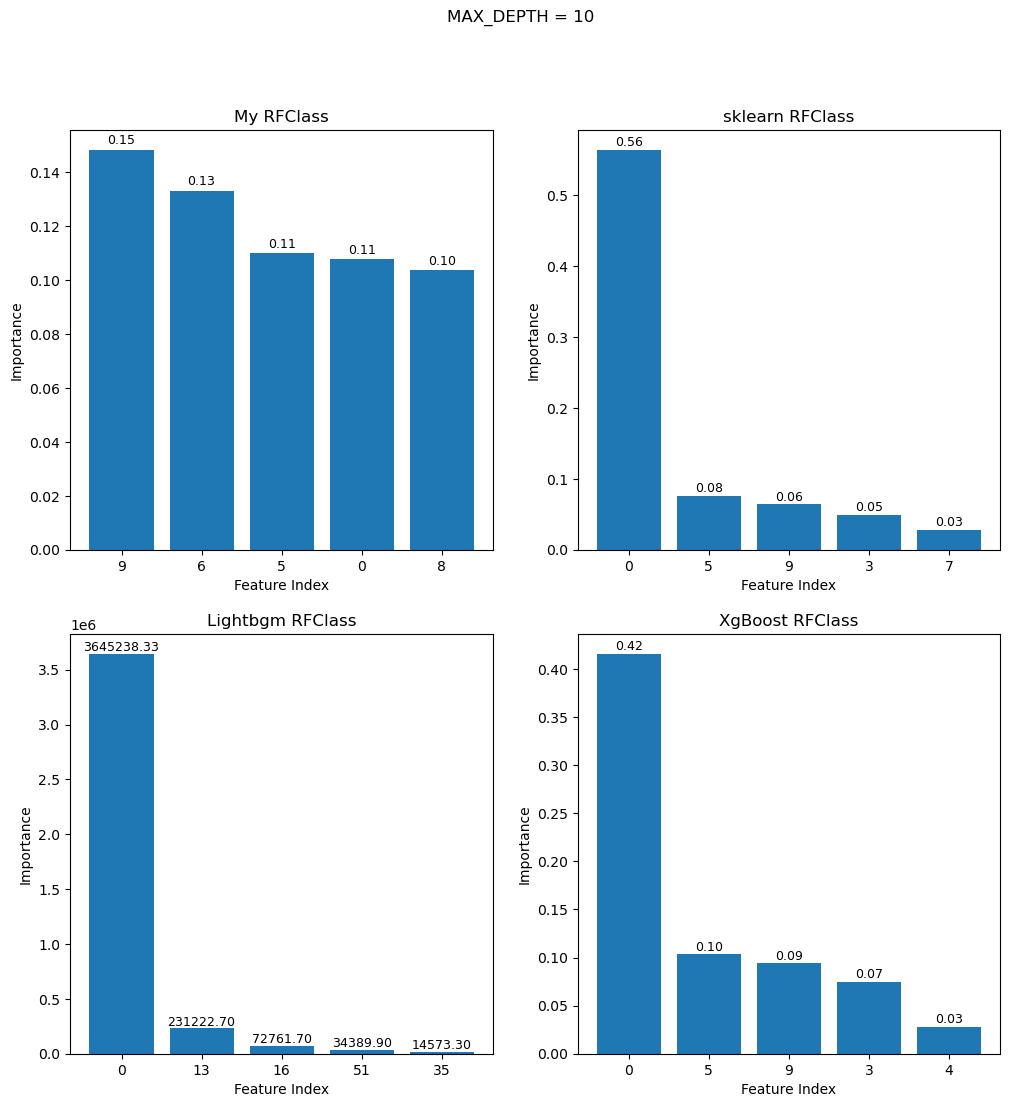

In [20]:

depths =  [2, 5, 7, 10]

feature_imp = np.array(feature_imp)

for j, depth in enumerate(depths):
    print(j)
    imp = feature_imp[:, j, :]

    top5_idx = np.argsort(imp, axis=1)[:, -5:][:, ::-1]   

    # optional: descending order
    top5_vals = np.take_along_axis(imp, top5_idx, axis=1)

    n_groups = imp.shape[0]

    ig, axes = plt.subplots(2, 2, figsize=(12, 12))
    plt.suptitle(f'MAX_DEPTH = {depth}')

    for i in range(n_groups):
        axes[i//2, i%2].bar(np.arange(5), top5_vals[i].flatten())
    
        axes[i//2, i%2].set_title(f'{names[i]}')
        axes[i//2, i%2].set_xlabel('Feature Index')
        axes[i//2, i%2].set_ylabel('Importance')
    
        axes[i//2, i%2].set_xticks(np.arange(5), top5_idx[i].flatten())  # show exact indices

        for k, val in enumerate(top5_vals[i]):
            axes[i//2, i%2].text(k, val + 0.001, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    plt.show()
